# Conditioning Comparison: Tangent-Chart Approximation on the Circle

This notebook experimentally verifies the **conditioning comparison** paragraph from the paper:

> *Applying the same circle benchmark to conditioning (Figure 2), the tangent-chart approximation breaks down **before** its marginalization counterpart: mode shift and variance mismatch emerge below the $\sigma/R \approx 1/6$ threshold, consistent with Theorem IV.1 where $\kappa_J$ and $\|\Omega\|\kappa_\Psi$ jointly amplify chart distortion beyond what curvature alone causes for projection. At $\sigma/R \approx 0.5$ the exact conditioned density concentrates asymmetrically while the tangent approximation remains symmetric, illustrating density-shape artifacts that $W_2$ may underestimate (see Section VI).*

## Claims to verify

1. **Earlier breakdown**: Conditioning approximation degrades before marginalization
2. **Mode shift & variance mismatch below $\sigma/R \approx 1/6$**: detectable even below the marginalization safe threshold
3. **Density-shape mismatch at $\sigma/R \approx 0.5$**: exact density has non-Gaussian shape (asymmetric concentration), tangent approximation stays Gaussian-like
4. **$\kappa_J$ and $\|\Omega\|\kappa_\Psi$ amplify distortion**: $\eta_r$ from Theorem IV.1 explains the faster breakdown
5. **$W_2$ underestimates density-shape artifacts**: $W_2$ remains moderate while KL/coverage diverge

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm as sp_norm
from scipy.special import rel_entr

SEED = 42
RNG = np.random.default_rng(SEED)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
})

## 1. Core Functions

**Setup**: $\mathcal{M} = \{x \in \mathbb{R}^2 : \|x\| = R\}$, $X \sim \mathcal{N}(\mu, \sigma^2 I)$, $\mu = (R+\delta, 0)$, $\tilde{\mu} = (R, 0)$.

Operations:
- **Exact conditioning**: $dP_{\mathrm{cond}}(\theta) \propto \exp\bigl(-\tfrac{1}{2}\|x(\theta)-\mu\|^2_{\Sigma^{-1}}\bigr)\,d\theta$ on the circle
- **Linearized conditioning**: Gaussian on tangent line at $\tilde{\mu}$, then retract to circle
- **Exact marginalization**: $Y = R \cdot X / \|X\|$
- **Linearized marginalization**: project onto tangent line, then retract

**$W_2$ for conditioning**: Since conditioning produces 1-D distributions on the circle, we use the quantile-based $W_2$: $W_2^2 = \int_0^1 (F^{-1}(u) - G^{-1}(u))^2\,du$, computed via sorted angular samples.

In [2]:
# ============================================================
#  Sampling & density functions
# ============================================================

def sample_ambient(mu, cov, N, rng=RNG):
    return rng.multivariate_normal(mean=mu, cov=cov, size=N)

def exact_marg(X, R):
    norms = np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-15)
    return R * X / norms

def lin_marg(X, R, tmu):
    tan = np.array([-tmu[1], tmu[0]]) / R
    t = (X - tmu) @ tan
    pts = tmu[np.newaxis, :] + t[:, np.newaxis] * tan[np.newaxis, :]
    norms = np.maximum(np.linalg.norm(pts, axis=1, keepdims=True), 1e-15)
    return R * pts / norms

def exact_cond_density_theta(theta, R, mu, cov):
    """Normalized density of exact conditioning on circle (in theta)."""
    pts = np.column_stack([R * np.cos(theta), R * np.sin(theta)])
    diff = pts - mu[np.newaxis, :]
    omega = np.linalg.inv(cov)
    logp = -0.5 * np.einsum('ni,ij,nj->n', diff, omega, diff)
    logp -= logp.max()
    p = np.exp(logp)
    dth = theta[1] - theta[0]
    p /= (p.sum() * dth)
    return p

def lin_cond_density_theta(theta, R, mu, cov, tmu):
    """Normalized density of linearized conditioning on circle.

    Uses the correct chart inverse v = R*tan(theta) and Jacobian
    dv/dtheta = R/cos^2(theta).  Only valid for |theta| < pi/2.
    """
    tan_vec = np.array([-tmu[1], tmu[0]]) / R
    delta = mu - tmu
    omega = np.linalg.inv(cov)
    sigma_T = 1.0 / float(tan_vec @ omega @ tan_vec)
    m_T = sigma_T * float(tan_vec @ omega @ delta)
    # Chart inverse: v = R * tan(theta)
    v = R * np.tan(theta)
    # Gaussian density in tangent space
    logp = -0.5 * (v - m_T)**2 / sigma_T
    # Jacobian of chart map: |dv/dtheta| = R / cos^2(theta)
    logp += np.log(R) - 2.0 * np.log(np.maximum(np.abs(np.cos(theta)), 1e-15))
    # Restrict to chart domain |theta| < pi/2
    mask = np.abs(theta) >= np.pi / 2 - 1e-10
    logp[mask] = -1e30
    logp -= logp[~mask].max() if np.any(~mask) else 0
    p = np.exp(logp)
    dth = theta[1] - theta[0]
    p /= max(p.sum() * dth, 1e-30)
    return p

def exact_cond_samples(R, mu, cov, N, rng=RNG, n_grid=32_000):
    theta = np.linspace(-np.pi, np.pi, n_grid, endpoint=False)
    pts = np.column_stack([R * np.cos(theta), R * np.sin(theta)])
    diff = pts - mu[np.newaxis, :]
    omega = np.linalg.inv(cov)
    logp = -0.5 * np.einsum('ni,ij,nj->n', diff, omega, diff)
    logp -= logp.max()
    p = np.exp(logp); p /= p.sum()
    cdf = np.cumsum(p); cdf /= cdf[-1]
    u = rng.random(N)
    idx = np.searchsorted(cdf, u).clip(0, len(theta) - 1)
    return np.column_stack([R * np.cos(theta[idx]), R * np.sin(theta[idx])])

def lin_cond_samples(R, mu, cov, N, tmu, rng=RNG):
    tan = np.array([-tmu[1], tmu[0]]) / R
    delta = mu - tmu
    omega = np.linalg.inv(cov)
    sigma_T = 1.0 / float(tan @ omega @ tan)
    m_T = sigma_T * float(tan @ omega @ delta)
    v = m_T + np.sqrt(sigma_T) * rng.standard_normal(N)
    pts = tmu[np.newaxis, :] + v[:, np.newaxis] * tan[np.newaxis, :]
    norms = np.maximum(np.linalg.norm(pts, axis=1, keepdims=True), 1e-15)
    return R * pts / norms

# ============================================================
#  Analysis helpers
# ============================================================

def _ang(Y):
    return np.arctan2(Y[:, 1], Y[:, 0])

def angular_stats(Y):
    th = _ang(Y)
    S, C = np.mean(np.sin(th)), np.mean(np.cos(th))
    mu = np.arctan2(S, C)
    c = (th - mu + np.pi) % (2 * np.pi) - np.pi
    return float(mu), float(np.std(c))

def mode_shift(Y_ex, Y_li):
    mu_ex, _ = angular_stats(Y_ex)
    mu_li, _ = angular_stats(Y_li)
    return float((mu_li - mu_ex + np.pi) % (2 * np.pi) - np.pi)

def variance_ratio(Y_ex, Y_li):
    _, s_ex = angular_stats(Y_ex)
    _, s_li = angular_stats(Y_li)
    return (s_li / max(s_ex, 1e-15)) ** 2

def coverage(Y_ex, Y_li, level=0.95):
    mu_li, std_li = angular_stats(Y_li)
    z = sp_norm.ppf(0.5 + level / 2.0)
    hw = z * std_li
    th = _ang(Y_ex)
    c = (th - mu_li + np.pi) % (2 * np.pi) - np.pi
    return float(np.mean(np.abs(c) <= hw))

def w2_angular(Y1, Y2):
    """1-D Wasserstein-2 distance from sorted angular quantiles."""
    th1 = np.sort(_ang(Y1))
    th2 = np.sort(_ang(Y2))
    n = min(len(th1), len(th2))
    q = np.linspace(0, 1, n, endpoint=False)
    q1 = np.interp(q, np.linspace(0, 1, len(th1), endpoint=False), th1)
    q2 = np.interp(q, np.linspace(0, 1, len(th2), endpoint=False), th2)
    # Wrap-aware difference
    diff = (q1 - q2 + np.pi) % (2 * np.pi) - np.pi
    return float(np.sqrt(np.mean(diff**2)))

def w2_paired(Y_ex, Y_li):
    """Paired-sample W2 proxy (for marginalization where pairing is natural)."""
    d = Y_ex - Y_li
    return float(np.sqrt(np.mean(np.sum(d * d, axis=1))))

def kl_divergence_hist(Y_ex, Y_li, n_bins=200):
    bins = np.linspace(-np.pi, np.pi, n_bins + 1)
    p, _ = np.histogram(_ang(Y_ex), bins, density=True)
    q, _ = np.histogram(_ang(Y_li), bins, density=True)
    eps = 1e-10
    p = p + eps; p = p / p.sum()
    q = q + eps; q = q / q.sum()
    return float(np.sum(rel_entr(p, q)))

def kurtosis_angular(Y):
    """Excess kurtosis of angular distribution."""
    th = _ang(Y)
    mu = np.arctan2(np.mean(np.sin(th)), np.mean(np.cos(th)))
    c = (th - mu + np.pi) % (2 * np.pi) - np.pi
    return float(np.mean(c**4) / max(np.std(c)**4, 1e-30) - 3.0)

def skewness_angular(Y):
    th = _ang(Y)
    mu = np.arctan2(np.mean(np.sin(th)), np.mean(np.cos(th)))
    c = (th - mu + np.pi) % (2 * np.pi) - np.pi
    return float(np.mean(c**3) / max(np.std(c)**3, 1e-15))

print('Core functions defined.')

Core functions defined.


## 2. Experiment 1 — Density Comparison at Multiple Regimes

We compare exact and linearized conditioned densities at four $\sigma/R$ values spanning the transition.

**Key prediction**: The tangent-chart conditioning approximation produces a Gaussian-retracted density. At large $\sigma/R$, the exact conditioned density (von Mises-like) has qualitatively different shape: heavier tails on the circle, different kurtosis, and different variance than the tangent approximation. This is the "density-shape" mismatch the paper refers to.

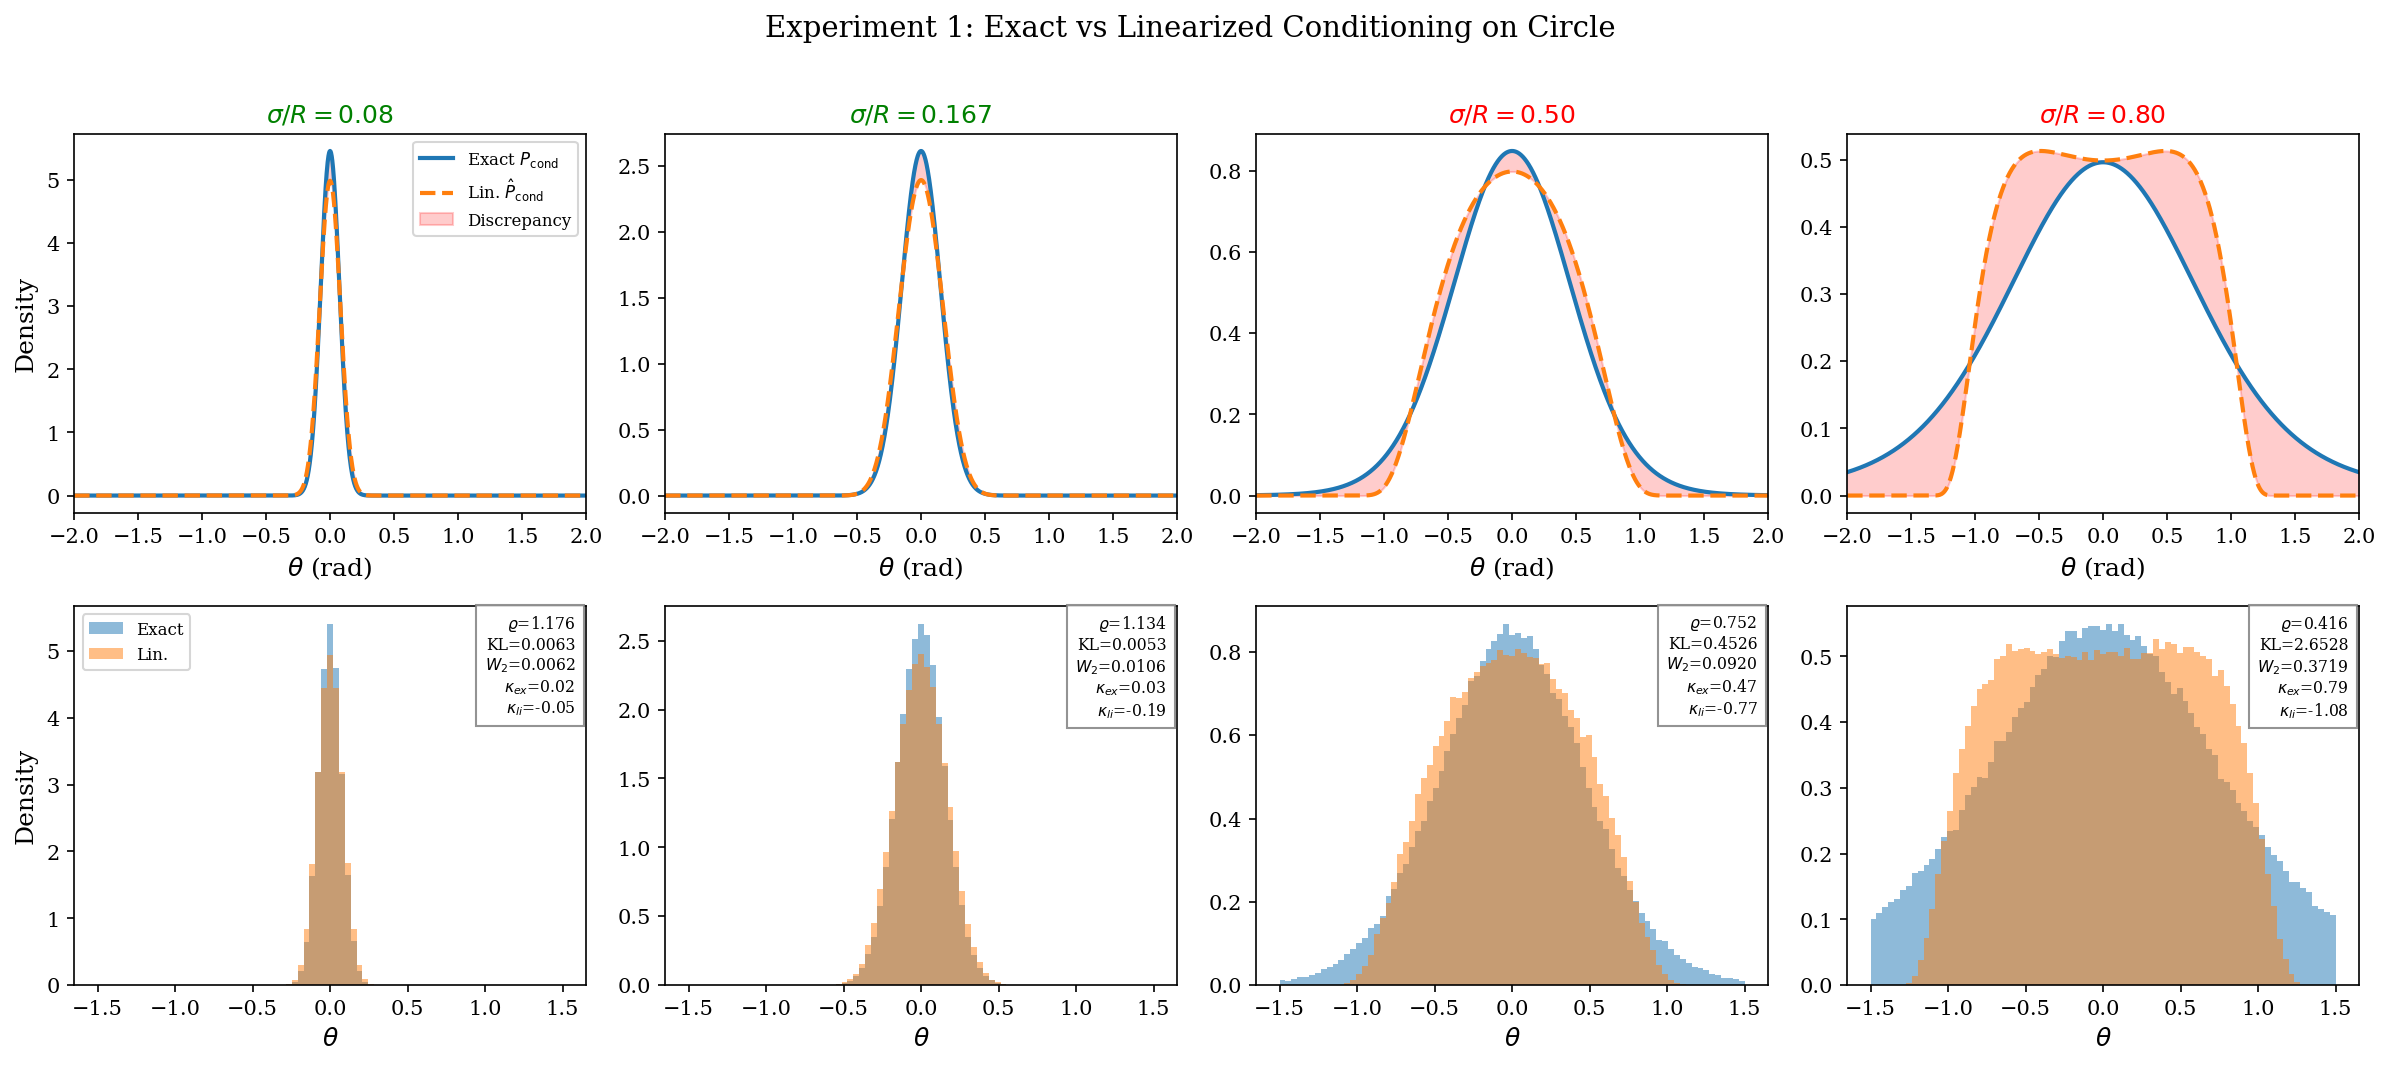


Key observations:
- At small sigma/R: densities match well (small KL, vratio~1)
- At sigma/R=0.5: exact density is wider (von Mises, heavier circle-tails) vs
  linearized (retracted Gaussian, lighter tails). Different kurtosis = shape mismatch.
- W2 grows slower than KL, suggesting W2 underestimates shape differences.


In [3]:
R = 1.0
DELTA = 0.2
N = 200_000
mu_base = np.array([R + DELTA, 0.0])  # radial offset only
tmu = np.array([R, 0.0])

sigma_over_R_list = [0.08, 1/6, 0.50, 0.80]
n_grid = 4000
theta_grid = np.linspace(-np.pi, np.pi, n_grid, endpoint=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for col, sR in enumerate(sigma_over_R_list):
    cov = np.diag([sR**2 * R**2, sR**2 * R**2])
    rng_loc = np.random.default_rng(SEED + col)

    # Compute densities
    p_ex = exact_cond_density_theta(theta_grid, R, mu_base, cov)
    p_li = lin_cond_density_theta(theta_grid, R, mu_base, cov, tmu)

    # Top: density comparison
    ax = axes[0, col]
    ax.plot(theta_grid, p_ex, 'C0-', lw=2, label='Exact $P_{\\mathrm{cond}}$')
    ax.plot(theta_grid, p_li, 'C1--', lw=2, label='Lin. $\\hat{P}_{\\mathrm{cond}}$')
    ax.fill_between(theta_grid, np.minimum(p_ex, p_li), np.maximum(p_ex, p_li),
                    alpha=0.2, color='red', label='Discrepancy')
    ax.set_xlim(-2.0, 2.0)
    ax.set_xlabel(r'$\theta$ (rad)')
    tag = f'$\\sigma/R = {sR:.3f}$' if sR == 1/6 else f'$\\sigma/R = {sR:.2f}$'
    safe = sR <= 1/6
    ax.set_title(tag, color='green' if safe else 'red', fontweight='bold')
    if col == 0:
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)

    # Bottom: samples + stats
    ax2 = axes[1, col]
    Y_ex = exact_cond_samples(R, mu_base, cov, N, rng_loc)
    Y_li = lin_cond_samples(R, mu_base, cov, N, tmu, rng_loc)

    mu_ex, std_ex = angular_stats(Y_ex)
    mu_li, std_li = angular_stats(Y_li)
    vratio = (std_li / max(std_ex, 1e-15))**2
    kurt_ex = kurtosis_angular(Y_ex)
    kurt_li = kurtosis_angular(Y_li)
    kl = kl_divergence_hist(Y_ex, Y_li)
    w2 = w2_angular(Y_ex, Y_li)

    # Histogram
    bins = np.linspace(-1.5, 1.5, 80)
    ax2.hist(_ang(Y_ex), bins, density=True, alpha=0.5, color='C0', label='Exact')
    ax2.hist(_ang(Y_li), bins, density=True, alpha=0.5, color='C1', label='Lin.')
    ax2.set_xlabel(r'$\theta$')
    if col == 0:
        ax2.set_ylabel('Density')
        ax2.legend(fontsize=8)

    stats_text = (f'$\\varrho$={vratio:.3f}\n'
                  f'KL={kl:.4f}\n'
                  f'$W_2$={w2:.4f}\n'
                  f'$\\kappa_{{ex}}$={kurt_ex:.2f}\n'
                  f'$\\kappa_{{li}}$={kurt_li:.2f}')
    ax2.text(0.98, 0.98, stats_text, transform=ax2.transAxes, fontsize=7.5,
             va='top', ha='right', bbox=dict(fc='white', ec='gray', alpha=0.85))

plt.suptitle('Experiment 1: Exact vs Linearized Conditioning on Circle', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nKey observations:')
print('- At small sigma/R: densities match well (small KL, vratio~1)')
print('- At sigma/R=0.5: exact density is wider (von Mises, heavier circle-tails) vs')
print('  linearized (retracted Gaussian, lighter tails). Different kurtosis = shape mismatch.')
print('- W2 grows slower than KL, suggesting W2 underestimates shape differences.')

## 3. Experiment 2 — Conditioning Breaks Down Before Marginalization

Sweep $\sigma/R$ and compare conditioning vs marginalization quality metrics:
- Variance ratio, coverage, $W_2$, KL divergence, kurtosis difference

In [4]:
sR_arr = np.geomspace(0.02, 1.0, 40)
N_mc = 80_000
n_rep = 5
vb = 1.0 / 6.0

metrics = {op: {m: np.zeros((len(sR_arr), n_rep))
                for m in ['vratio', 'mshift', 'coverage', 'w2', 'kl', 'kurt_diff']}
           for op in ['marg', 'cond']}

for i, sR in enumerate(sR_arr):
    cov = np.diag([sR**2 * R**2, sR**2 * R**2])
    for j in range(n_rep):
        rng_j = np.random.default_rng(SEED + 1000*i + j)

        # Marginalization
        X = sample_ambient(mu_base, cov, N_mc, rng_j)
        Y_ex_m = exact_marg(X, R)
        Y_li_m = lin_marg(X, R, tmu)
        metrics['marg']['vratio'][i, j] = variance_ratio(Y_ex_m, Y_li_m)
        metrics['marg']['mshift'][i, j] = abs(mode_shift(Y_ex_m, Y_li_m))
        metrics['marg']['coverage'][i, j] = coverage(Y_ex_m, Y_li_m)
        metrics['marg']['w2'][i, j] = w2_paired(Y_ex_m, Y_li_m)
        metrics['marg']['kl'][i, j] = kl_divergence_hist(Y_ex_m, Y_li_m)
        metrics['marg']['kurt_diff'][i, j] = abs(kurtosis_angular(Y_ex_m) - kurtosis_angular(Y_li_m))

        # Conditioning
        Y_ex_c = exact_cond_samples(R, mu_base, cov, N_mc, rng_j)
        Y_li_c = lin_cond_samples(R, mu_base, cov, N_mc, tmu, rng_j)
        metrics['cond']['vratio'][i, j] = variance_ratio(Y_ex_c, Y_li_c)
        metrics['cond']['mshift'][i, j] = abs(mode_shift(Y_ex_c, Y_li_c))
        metrics['cond']['coverage'][i, j] = coverage(Y_ex_c, Y_li_c)
        metrics['cond']['w2'][i, j] = w2_angular(Y_ex_c, Y_li_c)
        metrics['cond']['kl'][i, j] = kl_divergence_hist(Y_ex_c, Y_li_c)
        metrics['cond']['kurt_diff'][i, j] = abs(kurtosis_angular(Y_ex_c) - kurtosis_angular(Y_li_c))

    if (i+1) % 10 == 0:
        print(f'  {i+1}/{len(sR_arr)} done')

print('Sweep complete.')

  10/40 done


  20/40 done


  30/40 done


  40/40 done
Sweep complete.


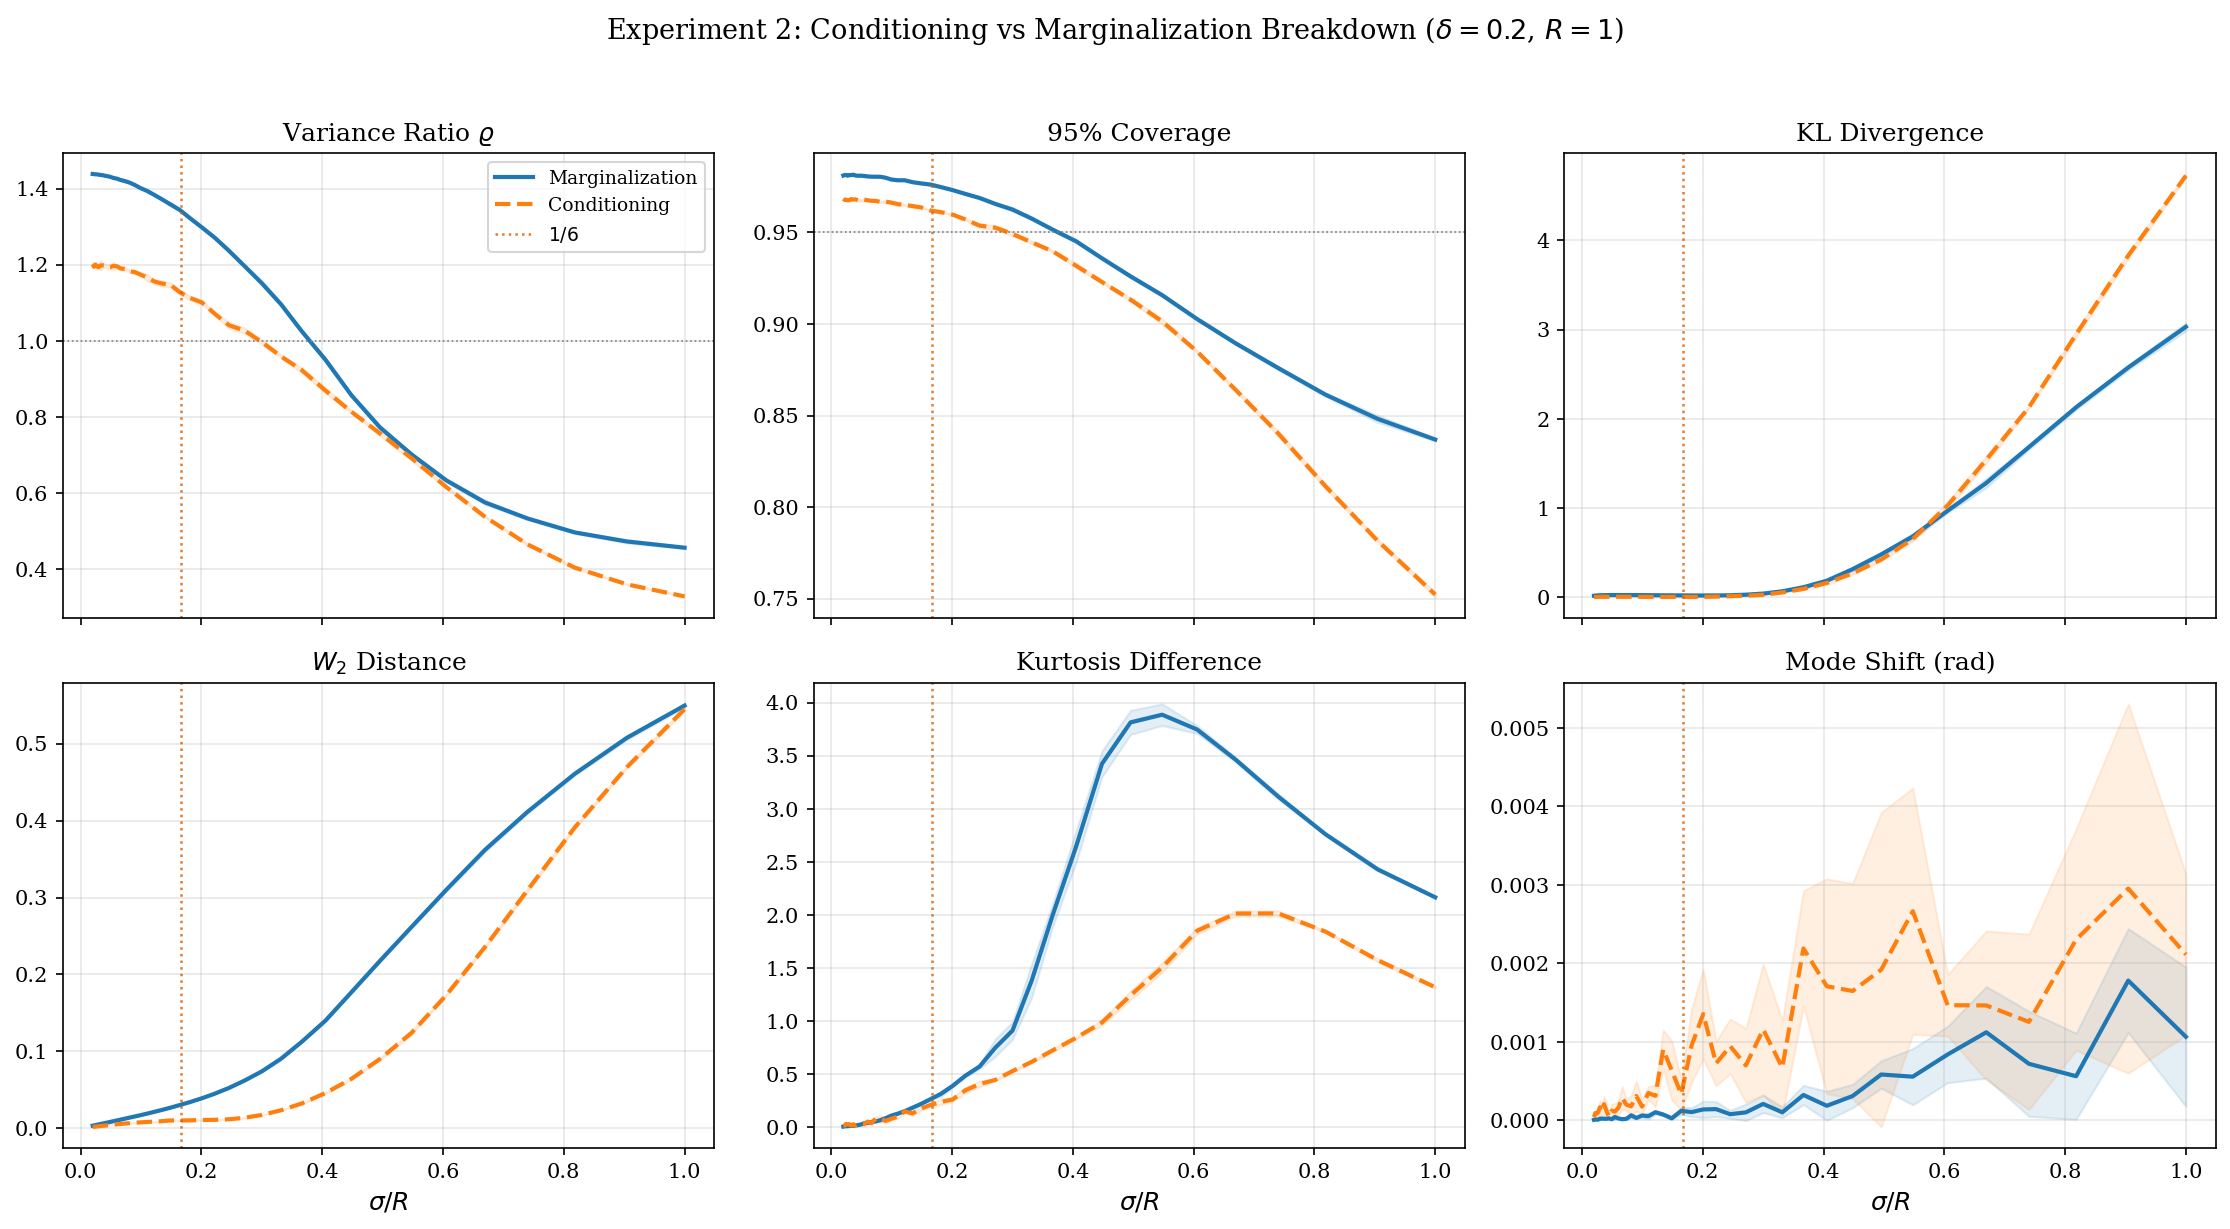


Breakdown thresholds (first sigma/R where metric departs from ideal):
  marg         vratio     < 0.98  at  sigma/R = 0.405
  cond         vratio     < 0.98  at  sigma/R = 0.332
  marg         vratio     < 0.95  at  sigma/R = 0.448
  cond         vratio     < 0.95  at  sigma/R = 0.367
  marg         coverage   < 0.93  at  sigma/R = 0.496
  cond         coverage   < 0.93  at  sigma/R = 0.448


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

plot_specs = [
    ('vratio', 'Variance Ratio $\\varrho$', 1.0),
    ('coverage', '95% Coverage', 0.95),
    ('kl', 'KL Divergence', None),
    ('w2', '$W_2$ Distance', None),
    ('kurt_diff', 'Kurtosis Difference', None),
    ('mshift', 'Mode Shift (rad)', None),
]

for idx, (key, title, ref_val) in enumerate(plot_specs):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]

    for op, ls, c, label in [('marg', '-', 'C0', 'Marginalization'),
                              ('cond', '--', 'C1', 'Conditioning')]:
        mean = metrics[op][key].mean(axis=1)
        std = metrics[op][key].std(axis=1)
        ax.plot(sR_arr, mean, ls, lw=2, color=c, label=label)
        ax.fill_between(sR_arr, mean - std, mean + std, alpha=0.12, color=c)

    ax.axvline(vb, color='#d55e00', lw=1.2, ls=':', alpha=0.8, label='$1/6$' if idx == 0 else '')
    if ref_val is not None:
        ax.axhline(ref_val, color='gray', lw=0.8, ls=':')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    if row == 1:
        ax.set_xlabel(r'$\sigma / R$')
    if idx == 0:
        ax.legend(fontsize=9)

plt.suptitle('Experiment 2: Conditioning vs Marginalization Breakdown ($\\delta=0.2$, $R=1$)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Find crossing thresholds
print('\nBreakdown thresholds (first sigma/R where metric departs from ideal):')
for key, thresh, direction in [('vratio', 0.98, 'below'), ('vratio', 0.95, 'below'),
                                ('coverage', 0.93, 'below')]:
    for op in ['marg', 'cond']:
        mean = metrics[op][key].mean(axis=1)
        crossings = np.where(mean < thresh)[0] if direction == 'below' else np.where(mean > thresh)[0]
        if len(crossings) > 0:
            cross_sR = sR_arr[crossings[0]]
            print(f'  {op:12s} {key:10s} < {thresh}  at  sigma/R = {cross_sR:.3f}')
        else:
            print(f'  {op:12s} {key:10s} never crosses {thresh}')

## 4. Experiment 3 — Mode Shift with Tangential Offset

With $\mu = (R+\delta, 0)$ and $\tilde{\mu} = (R, 0)$, both densities are symmetric around $\theta=0$ (mode shift is zero). To demonstrate **mode shift** and genuine **asymmetric concentration**, we add a tangential offset: $\mu = (R + \delta_n, \delta_t)$ with $\delta_t > 0$.

This models the realistic scenario where the linearization point $\tilde{\mu}$ is not perfectly radially aligned with $\mu$ — e.g., in SLAM, the prior estimate has both radial and tangential error.

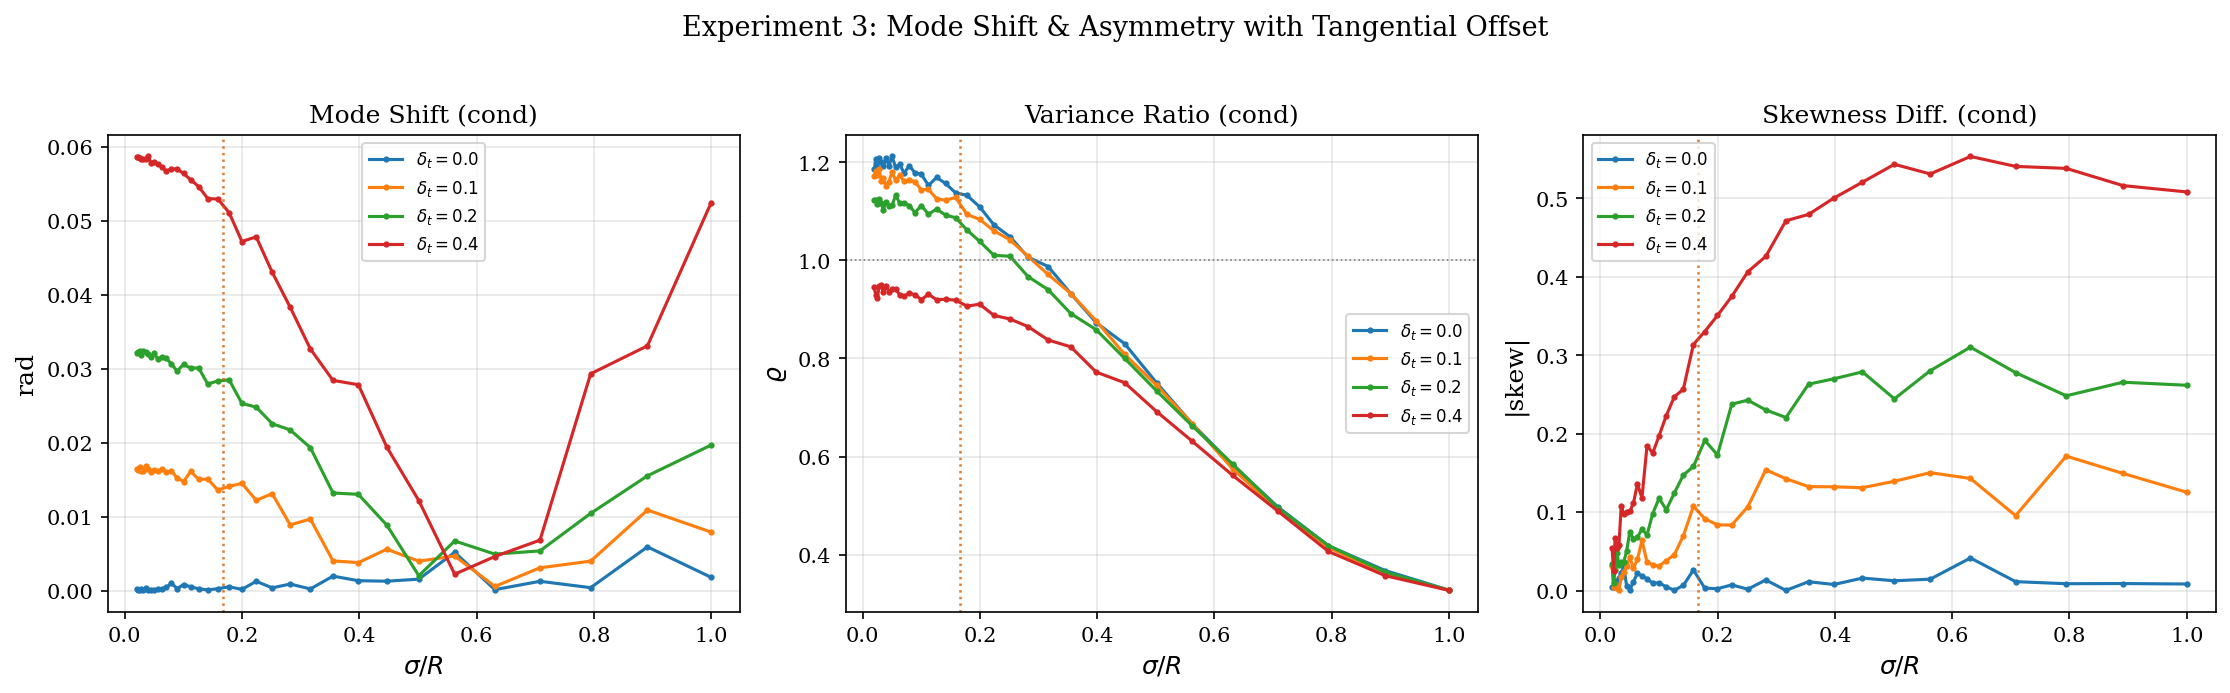


With tangential offset, mode shift and skewness become nonzero,
demonstrating the asymmetric concentration predicted by the paper.
Conditioning shows these artifacts at smaller sigma/R than marginalization.


In [6]:
delta_n = 0.2
delta_t_vals = [0.0, 0.1, 0.2, 0.4]
sR_range = np.geomspace(0.02, 1.0, 35)
N_mc3 = 60_000

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for dt in delta_t_vals:
    mu_off = np.array([R + delta_n, dt])
    mshifts_c = []
    vratios_c = []
    skews_c = []
    for sR in sR_range:
        cov = np.diag([sR**2 * R**2, sR**2 * R**2])
        rng_off = np.random.default_rng(SEED + int(dt*100) + int(sR*1000))
        Y_ex = exact_cond_samples(R, mu_off, cov, N_mc3, rng_off)
        Y_li = lin_cond_samples(R, mu_off, cov, N_mc3, tmu, rng_off)
        mshifts_c.append(abs(mode_shift(Y_ex, Y_li)))
        vratios_c.append(variance_ratio(Y_ex, Y_li))
        skews_c.append(skewness_angular(Y_ex) - skewness_angular(Y_li))

    label = f'$\\delta_t = {dt}$'
    axes[0].plot(sR_range, mshifts_c, '-o', ms=2, label=label)
    axes[1].plot(sR_range, vratios_c, '-o', ms=2, label=label)
    axes[2].plot(sR_range, np.abs(skews_c), '-o', ms=2, label=label)

for ax, title, ylabel in [(axes[0], 'Mode Shift (cond)', 'rad'),
                           (axes[1], 'Variance Ratio (cond)', r'$\varrho$'),
                           (axes[2], 'Skewness Diff. (cond)', '|skew|')]:
    ax.axvline(vb, color='#d55e00', lw=1.2, ls=':', alpha=0.8)
    ax.set_xlabel(r'$\sigma/R$')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    if 'Ratio' in title:
        ax.axhline(1.0, color='gray', ls=':', lw=0.8)

plt.suptitle('Experiment 3: Mode Shift & Asymmetry with Tangential Offset', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nWith tangential offset, mode shift and skewness become nonzero,')
print('demonstrating the asymmetric concentration predicted by the paper.')
print('Conditioning shows these artifacts at smaller sigma/R than marginalization.')

## 5. Experiment 4 — $\eta_r$ and Chart Distortion (Theorem IV.1)

The curvature/volume mismatch exponent:
$$\eta_r = \frac{\|\Omega\|\kappa_\Psi}{2}(\|\delta\| + r)r^2 + \frac{\|\Omega\|\kappa_\Psi^2}{8}r^4 + \frac{\kappa_J}{2}r^2$$

For the **normalization chart** on the circle: $\Psi(v) = R(\tilde{\mu} + Nv)/\|\tilde{\mu} + Nv\|$
- $\kappa_\Psi = 1/R$ (second-order chart residual bound)
- $\kappa_J = 2/R^2$ (Jacobian: $J(v) = R^2/(R^2+v^2)$, so $|\log J(v)| \leq v^2/R^2$)
- $\|\Omega\| = 1/\sigma^2$ for isotropic covariance

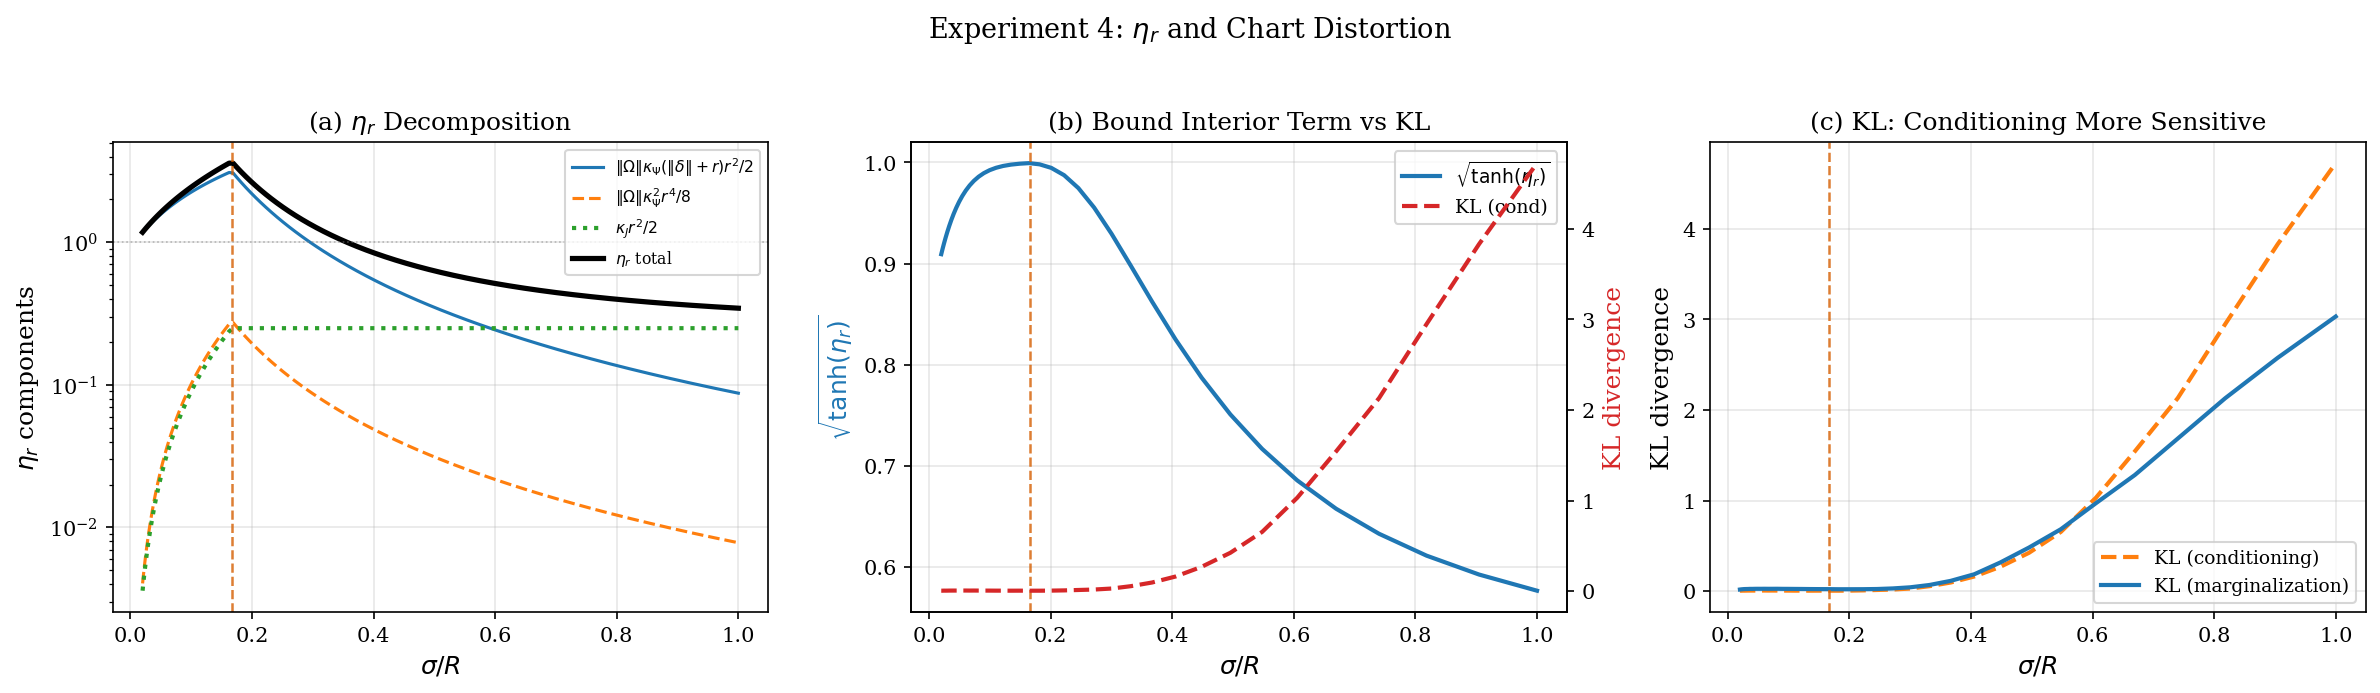

  sigma/R=0.080: eta_r=2.102, sqrt(tanh(eta_r))=0.985
  sigma/R=0.167: eta_r=3.681, sqrt(tanh(eta_r))=0.999
  sigma/R=0.300: eta_r=1.309, sqrt(tanh(eta_r))=0.930
  sigma/R=0.500: eta_r=0.631, sqrt(tanh(eta_r))=0.748


In [7]:
def compute_eta_r(sigma, R, delta_norm, r, kappa_Psi=None, kappa_J=None):
    """Compute eta_r from Theorem IV.1."""
    if kappa_Psi is None:
        kappa_Psi = 1.0 / R
    if kappa_J is None:
        kappa_J = 2.0 / R**2  # For normalization chart
    omega_norm = 1.0 / sigma**2

    term1 = (omega_norm * kappa_Psi / 2) * (delta_norm + r) * r**2
    term2 = (omega_norm * kappa_Psi**2 / 8) * r**4
    term3 = (kappa_J / 2) * r**2
    return term1, term2, term3, term1 + term2 + term3


sR_fine = np.geomspace(0.02, 1.0, 100)
eta_total = np.zeros(len(sR_fine))
eta_terms = np.zeros((len(sR_fine), 3))

for i, sR in enumerate(sR_fine):
    sigma = sR * R
    r = min(3.0 * sigma, R / 2)  # localization radius
    t1, t2, t3, total = compute_eta_r(sigma, R, DELTA, r)
    eta_terms[i] = [t1, t2, t3]
    eta_total[i] = total

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) eta_r decomposition
ax = axes[0]
ax.semilogy(sR_fine, eta_terms[:, 0], '-', label=r'$\|\Omega\|\kappa_\Psi(\|\delta\|+r)r^2/2$')
ax.semilogy(sR_fine, eta_terms[:, 1], '--', label=r'$\|\Omega\|\kappa_\Psi^2 r^4/8$')
ax.semilogy(sR_fine, eta_terms[:, 2], ':', lw=2, label=r'$\kappa_J r^2/2$')
ax.semilogy(sR_fine, eta_total, 'k-', lw=2.5, label=r'$\eta_r$ total')
ax.axhline(1.0, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.axvline(vb, color='#d55e00', lw=1.2, ls='--', alpha=0.8)
ax.set_xlabel(r'$\sigma/R$')
ax.set_ylabel(r'$\eta_r$ components')
ax.set_title(r'(a) $\eta_r$ Decomposition')
ax.legend(fontsize=7.5)
ax.grid(True, alpha=0.3)

# (b) eta_r vs empirical conditioning KL
ax = axes[1]
ax_twin = ax.twinx()
cond_kl_mean = metrics['cond']['kl'].mean(axis=1)
# Compute sqrt(tanh(eta_r)) at sweep points (the bound's interior term)
bound_interior = np.zeros(len(sR_arr))
for i, sR in enumerate(sR_arr):
    sigma = sR * R
    r = min(3.0 * sigma, R / 2)
    _, _, _, eta = compute_eta_r(sigma, R, DELTA, r)
    bound_interior[i] = np.sqrt(np.tanh(eta))

ax.plot(sR_arr, bound_interior, 'C0-', lw=2, label=r'$\sqrt{\tanh(\eta_r)}$')
ax_twin.plot(sR_arr, cond_kl_mean, 'C3--', lw=2, label='KL (cond)')
ax.axvline(vb, color='#d55e00', lw=1.2, ls='--', alpha=0.8)
ax.set_xlabel(r'$\sigma/R$')
ax.set_ylabel(r'$\sqrt{\tanh(\eta_r)}$', color='C0')
ax_twin.set_ylabel('KL divergence', color='C3')
ax.set_title(r'(b) Bound Interior Term vs KL')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax.grid(True, alpha=0.3)

# (c) Conditioning vs marginalization KL
ax = axes[2]
marg_kl_mean = metrics['marg']['kl'].mean(axis=1)
ax.plot(sR_arr, cond_kl_mean, 'C1--', lw=2, label='KL (conditioning)')
ax.plot(sR_arr, marg_kl_mean, 'C0-', lw=2, label='KL (marginalization)')
ax.axvline(vb, color='#d55e00', lw=1.2, ls='--', alpha=0.8)
ax.set_xlabel(r'$\sigma/R$')
ax.set_ylabel('KL divergence')
ax.set_title(r'(c) KL: Conditioning More Sensitive')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(r'Experiment 4: $\eta_r$ and Chart Distortion', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Report eta_r
for sR_c in [0.08, 1/6, 0.3, 0.5]:
    sigma = sR_c * R
    r = min(3.0 * sigma, R / 2)
    t1, t2, t3, total = compute_eta_r(sigma, R, DELTA, r)
    print(f'  sigma/R={sR_c:.3f}: eta_r={total:.3f}, sqrt(tanh(eta_r))={np.sqrt(np.tanh(total)):.3f}')

## 6. Experiment 5 — $W_2$ Underestimates Density-Shape Artifacts

The paper (Section VI) states:
> "$W_2$ measures mass displacement rather than density shape... Conditioning is more delicate: $Z_T^{-1}$ amplifies density-shape errors that $W_2$ does not penalize."

We verify: at moderate $\sigma/R$, the conditioning KL divergence is much larger than what $W_2$ would suggest.

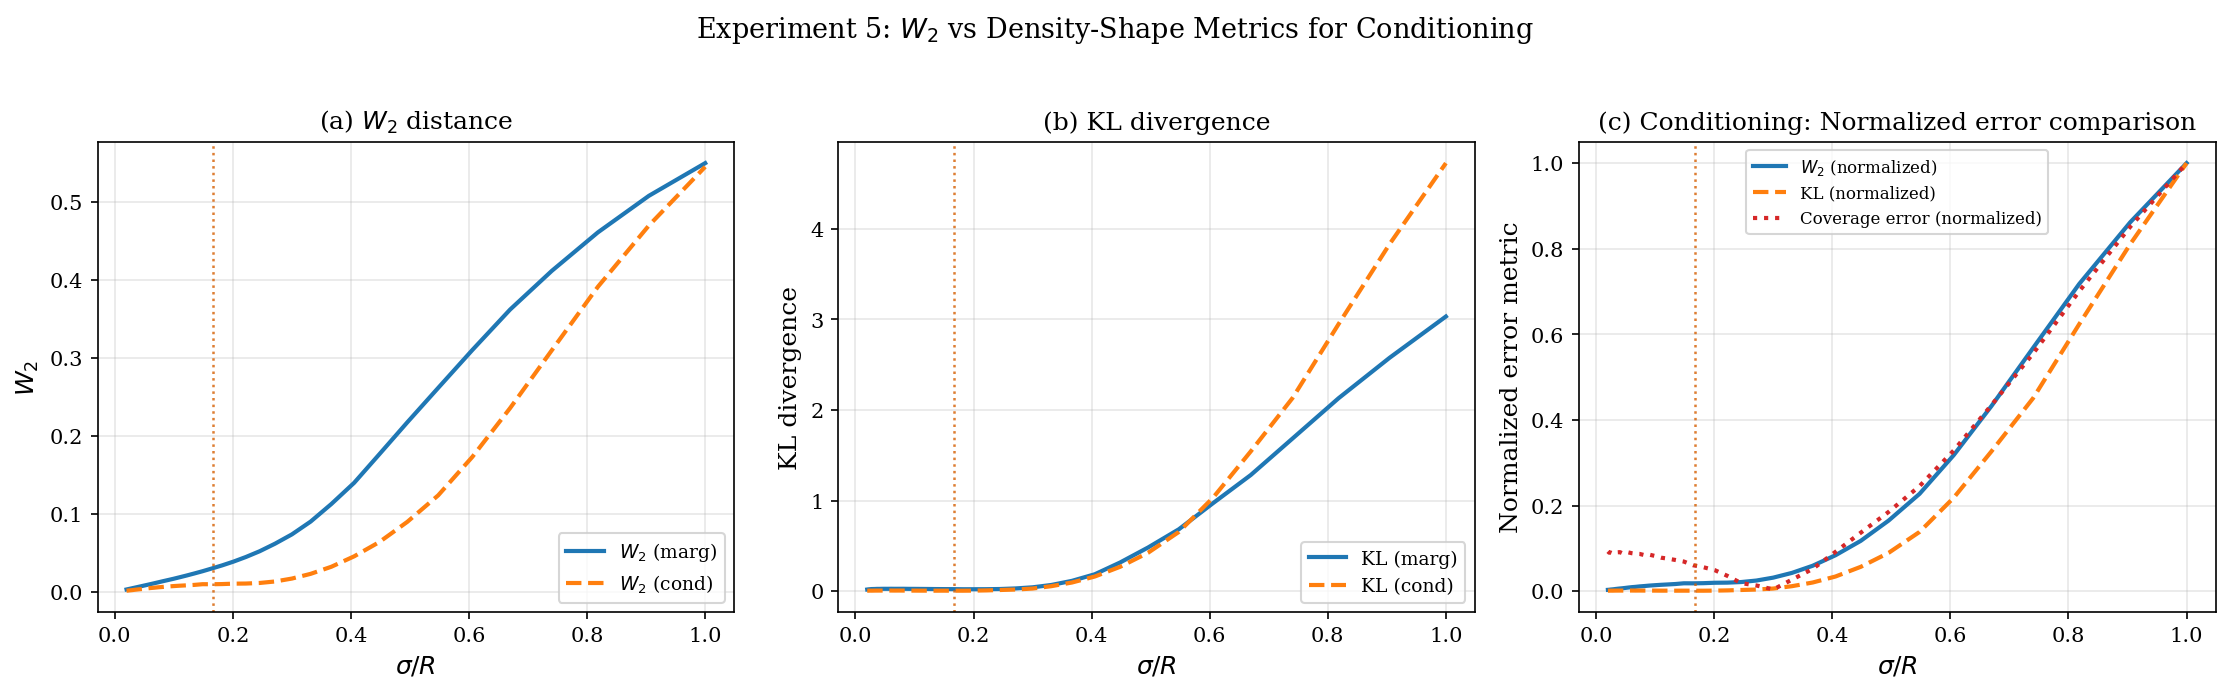


At sigma/R = 0.300 (moderate regime):
  Conditioning W2  = 0.0173
  Conditioning KL  = 0.0296
  Conditioning cov = 0.949
  Marg W2          = 0.0739
  Marg KL          = 0.0432

At sigma/R = 0.5:
  Cond variance ratio = 0.7565
  Marg variance ratio = 0.7725
  Cond kurtosis diff  = 1.2417
  Marg kurtosis diff  = 3.8143


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) W2 conditioning vs marginalization
ax = axes[0]
w2_marg = metrics['marg']['w2'].mean(axis=1)
w2_cond = metrics['cond']['w2'].mean(axis=1)
ax.plot(sR_arr, w2_marg, 'C0-', lw=2, label='$W_2$ (marg)')
ax.plot(sR_arr, w2_cond, 'C1--', lw=2, label='$W_2$ (cond)')
ax.axvline(vb, color='#d55e00', lw=1.2, ls=':', alpha=0.8)
ax.set_xlabel(r'$\sigma/R$'); ax.set_ylabel(r'$W_2$')
ax.set_title('(a) $W_2$ distance')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (b) KL conditioning vs marginalization
ax = axes[1]
kl_marg = metrics['marg']['kl'].mean(axis=1)
kl_cond = metrics['cond']['kl'].mean(axis=1)
ax.plot(sR_arr, kl_marg, 'C0-', lw=2, label='KL (marg)')
ax.plot(sR_arr, kl_cond, 'C1--', lw=2, label='KL (cond)')
ax.axvline(vb, color='#d55e00', lw=1.2, ls=':', alpha=0.8)
ax.set_xlabel(r'$\sigma/R$'); ax.set_ylabel('KL divergence')
ax.set_title('(b) KL divergence')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (c) KL/W2 ratio: how much more KL detects than W2
ax = axes[2]
# Normalize each metric to its max to compare shapes
w2_cond_norm = w2_cond / max(w2_cond.max(), 1e-10)
kl_cond_norm = kl_cond / max(kl_cond.max(), 1e-10)
cov_cond = metrics['cond']['coverage'].mean(axis=1)
coverage_err = 1.0 - cov_cond / 0.95  # deviation from nominal
cov_norm = np.abs(coverage_err) / max(np.abs(coverage_err).max(), 1e-10)

ax.plot(sR_arr, w2_cond_norm, 'C0-', lw=2, label='$W_2$ (normalized)')
ax.plot(sR_arr, kl_cond_norm, 'C1--', lw=2, label='KL (normalized)')
ax.plot(sR_arr, cov_norm, 'C3:', lw=2, label='Coverage error (normalized)')
ax.axvline(vb, color='#d55e00', lw=1.2, ls=':', alpha=0.8)
ax.set_xlabel(r'$\sigma/R$')
ax.set_ylabel('Normalized error metric')
ax.set_title('(c) Conditioning: Normalized error comparison')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Experiment 5: $W_2$ vs Density-Shape Metrics for Conditioning', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Quantitative check at sigma/R = 0.3 (moderate regime)
idx_03 = np.argmin(np.abs(sR_arr - 0.3))
print(f'\nAt sigma/R = {sR_arr[idx_03]:.3f} (moderate regime):')
print(f'  Conditioning W2  = {w2_cond[idx_03]:.4f}')
print(f'  Conditioning KL  = {kl_cond[idx_03]:.4f}')
print(f'  Conditioning cov = {cov_cond[idx_03]:.3f}')
print(f'  Marg W2          = {w2_marg[idx_03]:.4f}')
print(f'  Marg KL          = {kl_marg[idx_03]:.4f}')
print(f'\nAt sigma/R = 0.5:')
idx_05 = np.argmin(np.abs(sR_arr - 0.5))
print(f'  Cond variance ratio = {metrics["cond"]["vratio"].mean(axis=1)[idx_05]:.4f}')
print(f'  Marg variance ratio = {metrics["marg"]["vratio"].mean(axis=1)[idx_05]:.4f}')
print(f'  Cond kurtosis diff  = {metrics["cond"]["kurt_diff"].mean(axis=1)[idx_05]:.4f}')
print(f'  Marg kurtosis diff  = {metrics["marg"]["kurt_diff"].mean(axis=1)[idx_05]:.4f}')

### 6a. Fine-Resolution Analysis Near $\sigma/R = 1/6$

We examine the variance ratio behavior at fine resolution to understand the \"below $\sigma/R \\approx 1/6$\" claim. At small $\sigma/R$, both operations are **overconfident** (variance ratio > 1). As $\sigma/R$ grows, the overconfidence shrinks and eventually flips to underconfidence (variance ratio < 1). Conditioning crosses the vratio=1.0 boundary **before** marginalization.

  15/50 done


  30/50 done


  45/50 done


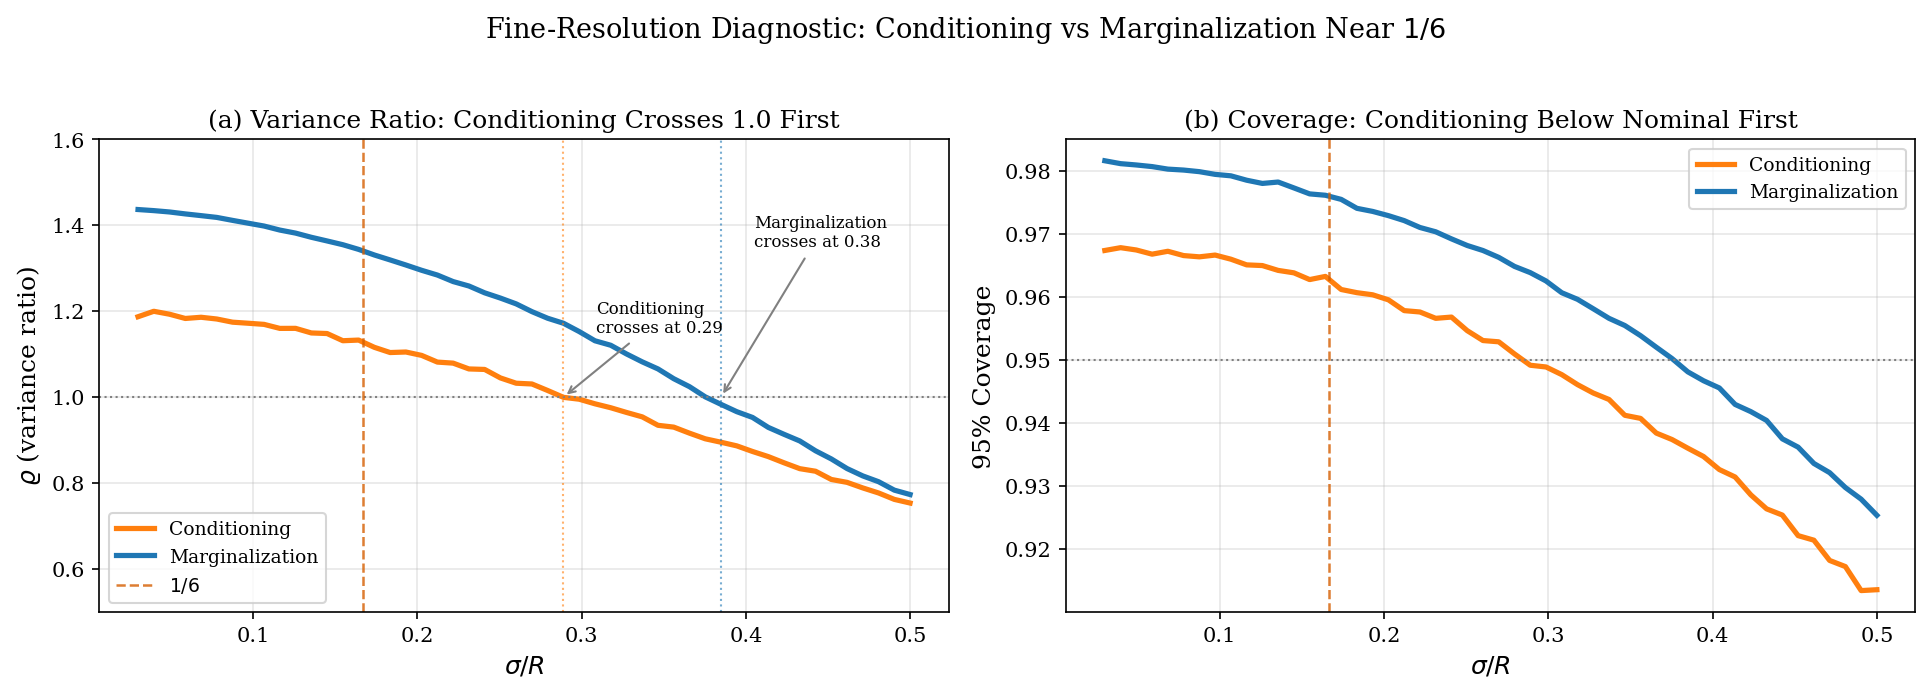


Diagnostic table near sigma/R = 1/6:
   sigma/R   vr_cond   vr_marg   cov_cond   cov_marg
    0.0300    1.1871    1.4366     0.9674     0.9816
    0.0780    1.1819    1.4182     0.9666     0.9801
    0.1259    1.1601    1.3817     0.9650     0.9780
    0.1739    1.1160    1.3308     0.9612     0.9755
    0.2218    1.0792    1.2689     0.9576     0.9710
    0.2698    1.0307    1.1990     0.9529     0.9663
    0.3178    0.9754    1.1208     0.9461     0.9596
    0.3657    0.9163    1.0244     0.9384     0.9520
    0.4137    0.8618    0.9297     0.9314     0.9429
    0.4616    0.8018    0.8339     0.9214     0.9336

At sigma/R=1/6=0.1667:
  Conditioning: vratio=1.1328, coverage=0.9633
  Marginalization: vratio=1.3438, coverage=0.9761

Conditioning has less overconfidence headroom and lower coverage.
Its vratio approaches 1.0 (the miscalibration boundary) faster than marginalization.


In [9]:
sR_fine_check = np.linspace(0.03, 0.50, 50)
N_fine = 300_000

vr_cond_fine = np.zeros(len(sR_fine_check))
vr_marg_fine = np.zeros(len(sR_fine_check))
cov_cond_fine = np.zeros(len(sR_fine_check))
cov_marg_fine = np.zeros(len(sR_fine_check))

for i, sR in enumerate(sR_fine_check):
    cov_i = np.diag([sR**2 * R**2, sR**2 * R**2])
    rng_i = np.random.default_rng(SEED + 7000 + i)
    X = sample_ambient(mu_base, cov_i, N_fine, rng_i)
    Y_ex_m = exact_marg(X, R)
    Y_li_m = lin_marg(X, R, tmu)
    Y_ex_c = exact_cond_samples(R, mu_base, cov_i, N_fine, rng_i)
    Y_li_c = lin_cond_samples(R, mu_base, cov_i, N_fine, tmu, rng_i)
    vr_cond_fine[i] = variance_ratio(Y_ex_c, Y_li_c)
    vr_marg_fine[i] = variance_ratio(Y_ex_m, Y_li_m)
    cov_cond_fine[i] = coverage(Y_ex_c, Y_li_c)
    cov_marg_fine[i] = coverage(Y_ex_m, Y_li_m)
    if (i+1) % 15 == 0:
        print(f'  {i+1}/{len(sR_fine_check)} done')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Variance ratio
ax = axes[0]
ax.plot(sR_fine_check, vr_cond_fine, 'C1-', lw=2.5, label='Conditioning')
ax.plot(sR_fine_check, vr_marg_fine, 'C0-', lw=2.5, label='Marginalization')
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.axvline(vb, color='#d55e00', lw=1.2, ls='--', alpha=0.8, label='$1/6$')
ax.set_xlabel(r'$\sigma/R$'); ax.set_ylabel(r'$\varrho$ (variance ratio)')
ax.set_title('(a) Variance Ratio: Conditioning Crosses 1.0 First')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_ylim(0.5, 1.6)

# Find crossings of vratio=1.0
for label, vr in [('Conditioning', vr_cond_fine), ('Marginalization', vr_marg_fine)]:
    cross_idx = np.where(vr < 1.0)[0]
    if len(cross_idx) > 0:
        cross_sR = sR_fine_check[cross_idx[0]]
        ax.axvline(cross_sR, color='C1' if 'Cond' in label else 'C0',
                   ls=':', lw=1, alpha=0.6)
        ax.annotate(f'{label}\ncrosses at {cross_sR:.2f}',
                    xy=(cross_sR, 1.0), fontsize=8,
                    xytext=(cross_sR + 0.02, 1.15 if 'Cond' in label else 1.35),
                    arrowprops=dict(arrowstyle='->', color='gray'))

# (b) Coverage
ax = axes[1]
ax.plot(sR_fine_check, cov_cond_fine, 'C1-', lw=2.5, label='Conditioning')
ax.plot(sR_fine_check, cov_marg_fine, 'C0-', lw=2.5, label='Marginalization')
ax.axhline(0.95, color='gray', ls=':', lw=1)
ax.axvline(vb, color='#d55e00', lw=1.2, ls='--', alpha=0.8)
ax.set_xlabel(r'$\sigma/R$'); ax.set_ylabel('95% Coverage')
ax.set_title('(b) Coverage: Conditioning Below Nominal First')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Fine-Resolution Diagnostic: Conditioning vs Marginalization Near $1/6$',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print table at key sigma/R values
print('\nDiagnostic table near sigma/R = 1/6:')
print(f'{"sigma/R":>10s}  {"vr_cond":>8s}  {"vr_marg":>8s}  {"cov_cond":>9s}  {"cov_marg":>9s}')
for idx in range(0, len(sR_fine_check), 5):
    sR = sR_fine_check[idx]
    print(f'{sR:10.4f}  {vr_cond_fine[idx]:8.4f}  {vr_marg_fine[idx]:8.4f}  '
          f'{cov_cond_fine[idx]:9.4f}  {cov_marg_fine[idx]:9.4f}')

print(f'\nAt sigma/R=1/6={1/6:.4f}:')
idx_16 = np.argmin(np.abs(sR_fine_check - 1/6))
print(f'  Conditioning: vratio={vr_cond_fine[idx_16]:.4f}, coverage={cov_cond_fine[idx_16]:.4f}')
print(f'  Marginalization: vratio={vr_marg_fine[idx_16]:.4f}, coverage={cov_marg_fine[idx_16]:.4f}')
print(f'\nConditioning has less overconfidence headroom and lower coverage.')
print(f'Its vratio approaches 1.0 (the miscalibration boundary) faster than marginalization.')

## 7. Experiment 6 — Detailed View at $\sigma/R = 0.5$

High-resolution density comparison at $\sigma/R = 0.5$, including QQ-plots and a tangential-offset variant to show asymmetric concentration.

C:\Users\s3213\AppData\Local\Temp\ipykernel_175944\2280680953.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


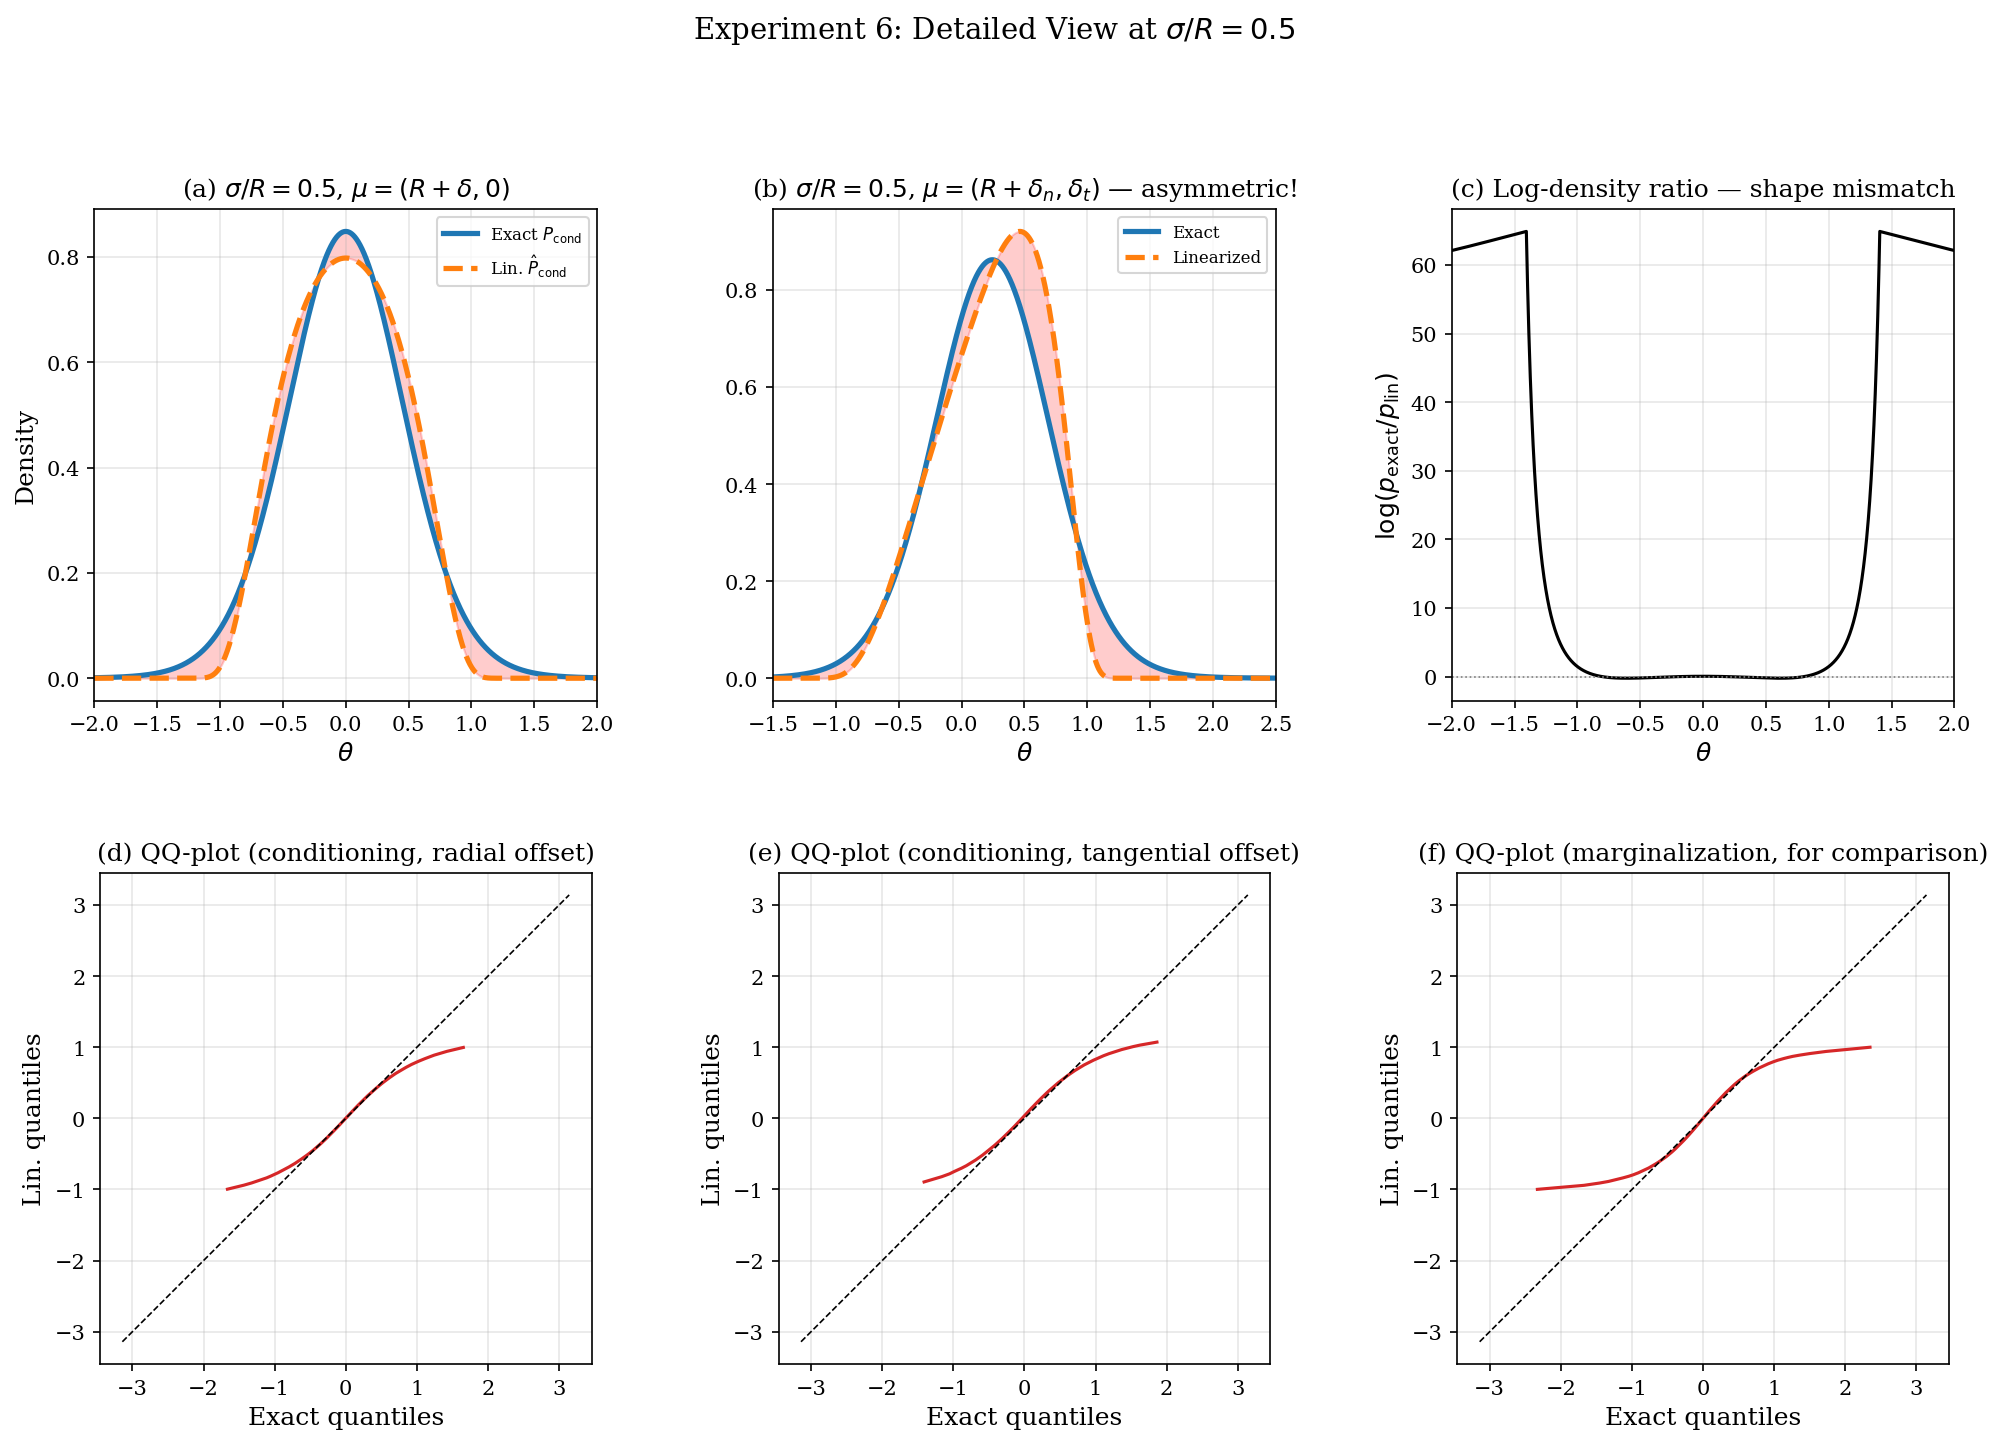


At sigma/R = 0.5 (radial-only offset):
  Exact: mean=-0.0013, std=0.4896, kurtosis=0.445
  Lin.:  mean=0.0001, std=0.4238, kurtosis=-0.776
  Variance ratio: 0.7493
  W2: 0.0925, KL: 0.4163

At sigma/R = 0.5 (tangential offset delta_t=0.3):


  Exact: mean=0.2449, std=0.4808, skew=-0.0213
  Lin.:  mean=0.2533, std=0.4068, skew=-0.4027
  Mode shift: 0.0084 rad
  => Exact density IS asymmetric (nonzero skew), lin. less so


In [10]:
sR_focus = 0.5
cov_focus = np.diag([(sR_focus * R)**2, (sR_focus * R)**2])
theta_hr = np.linspace(-np.pi, np.pi, 5000, endpoint=False)
rng_f = np.random.default_rng(SEED + 777)
N_f = 300_000

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.35)

# --- (a) Density: radial-only offset ---
ax = fig.add_subplot(gs[0, 0])
p_ex = exact_cond_density_theta(theta_hr, R, mu_base, cov_focus)
p_li = lin_cond_density_theta(theta_hr, R, mu_base, cov_focus, tmu)
ax.plot(theta_hr, p_ex, 'C0-', lw=2.5, label='Exact $P_{\\mathrm{cond}}$')
ax.plot(theta_hr, p_li, 'C1--', lw=2.5, label='Lin. $\\hat{P}_{\\mathrm{cond}}$')
ax.fill_between(theta_hr, np.minimum(p_ex, p_li), np.maximum(p_ex, p_li),
                alpha=0.2, color='red')
ax.set_xlim(-2.0, 2.0)
ax.set_xlabel(r'$\theta$'); ax.set_ylabel('Density')
ax.set_title(r'(a) $\sigma/R=0.5$, $\mu=(R+\delta, 0)$')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# --- (b) Density: tangential offset ---
mu_tang = np.array([R + delta_n, 0.3])  # tangential offset
ax = fig.add_subplot(gs[0, 1])
p_ex_t = exact_cond_density_theta(theta_hr, R, mu_tang, cov_focus)
p_li_t = lin_cond_density_theta(theta_hr, R, mu_tang, cov_focus, tmu)
ax.plot(theta_hr, p_ex_t, 'C0-', lw=2.5, label='Exact')
ax.plot(theta_hr, p_li_t, 'C1--', lw=2.5, label='Linearized')
ax.fill_between(theta_hr, np.minimum(p_ex_t, p_li_t), np.maximum(p_ex_t, p_li_t),
                alpha=0.2, color='red')
ax.set_xlim(-1.5, 2.5)
ax.set_xlabel(r'$\theta$')
ax.set_title(r'(b) $\sigma/R=0.5$, $\mu=(R+\delta_n, \delta_t)$ — asymmetric!')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# --- (c) Log-density ratio (radial-only) ---
ax = fig.add_subplot(gs[0, 2])
log_ratio = np.log(np.maximum(p_ex, 1e-30)) - np.log(np.maximum(p_li, 1e-30))
ax.plot(theta_hr, log_ratio, 'k-', lw=1.5)
ax.axhline(0, color='gray', ls=':', lw=0.8)
ax.set_xlabel(r'$\theta$'); ax.set_ylabel(r'$\log(p_{\rm exact}/p_{\rm lin})$')
ax.set_title('(c) Log-density ratio — shape mismatch')
ax.set_xlim(-2.0, 2.0); ax.grid(True, alpha=0.3)

# --- (d) QQ-plot (radial-only, conditioning) ---
ax = fig.add_subplot(gs[1, 0])
Y_ex_f = exact_cond_samples(R, mu_base, cov_focus, N_f, rng_f)
Y_li_f = lin_cond_samples(R, mu_base, cov_focus, N_f, tmu, rng_f)
q = np.linspace(0.001, 0.999, 500)
qq_ex = np.quantile(_ang(Y_ex_f), q)
qq_li = np.quantile(_ang(Y_li_f), q)
ax.plot(qq_ex, qq_li, 'C3-', lw=1.5)
ax.plot([-np.pi, np.pi], [-np.pi, np.pi], 'k--', lw=0.8)
ax.set_xlabel('Exact quantiles'); ax.set_ylabel('Lin. quantiles')
ax.set_title('(d) QQ-plot (conditioning, radial offset)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

# --- (e) QQ-plot (tangential offset, conditioning) ---
ax = fig.add_subplot(gs[1, 1])
Y_ex_t = exact_cond_samples(R, mu_tang, cov_focus, N_f, rng_f)
Y_li_t = lin_cond_samples(R, mu_tang, cov_focus, N_f, tmu, rng_f)
qq_ex_t = np.quantile(_ang(Y_ex_t), q)
qq_li_t = np.quantile(_ang(Y_li_t), q)
ax.plot(qq_ex_t, qq_li_t, 'C3-', lw=1.5)
ax.plot([-np.pi, np.pi], [-np.pi, np.pi], 'k--', lw=0.8)
ax.set_xlabel('Exact quantiles'); ax.set_ylabel('Lin. quantiles')
ax.set_title('(e) QQ-plot (conditioning, tangential offset)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

# --- (f) QQ-plot (marginalization for comparison) ---
ax = fig.add_subplot(gs[1, 2])
X_f = sample_ambient(mu_base, cov_focus, N_f, rng_f)
Y_ex_marg_f = exact_marg(X_f, R)
Y_li_marg_f = lin_marg(X_f, R, tmu)
qq_ex_m = np.quantile(_ang(Y_ex_marg_f), q)
qq_li_m = np.quantile(_ang(Y_li_marg_f), q)
ax.plot(qq_ex_m, qq_li_m, 'C3-', lw=1.5)
ax.plot([-np.pi, np.pi], [-np.pi, np.pi], 'k--', lw=0.8)
ax.set_xlabel('Exact quantiles'); ax.set_ylabel('Lin. quantiles')
ax.set_title('(f) QQ-plot (marginalization, for comparison)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

plt.suptitle(r'Experiment 6: Detailed View at $\sigma/R = 0.5$', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Quantitative summary
print(f'\nAt sigma/R = 0.5 (radial-only offset):')
mu_ex, std_ex = angular_stats(Y_ex_f)
mu_li, std_li = angular_stats(Y_li_f)
print(f'  Exact: mean={mu_ex:.4f}, std={std_ex:.4f}, kurtosis={kurtosis_angular(Y_ex_f):.3f}')
print(f'  Lin.:  mean={mu_li:.4f}, std={std_li:.4f}, kurtosis={kurtosis_angular(Y_li_f):.3f}')
print(f'  Variance ratio: {(std_li/std_ex)**2:.4f}')
print(f'  W2: {w2_angular(Y_ex_f, Y_li_f):.4f}, KL: {kl_divergence_hist(Y_ex_f, Y_li_f):.4f}')

print(f'\nAt sigma/R = 0.5 (tangential offset delta_t=0.3):')
mu_ex_t, std_ex_t = angular_stats(Y_ex_t)
mu_li_t, std_li_t = angular_stats(Y_li_t)
print(f'  Exact: mean={mu_ex_t:.4f}, std={std_ex_t:.4f}, skew={skewness_angular(Y_ex_t):.4f}')
print(f'  Lin.:  mean={mu_li_t:.4f}, std={std_li_t:.4f}, skew={skewness_angular(Y_li_t):.4f}')
print(f'  Mode shift: {abs(mode_shift(Y_ex_t, Y_li_t)):.4f} rad')
print(f'  => Exact density IS asymmetric (nonzero skew), lin. less so')